# Task 3 — Unsupervised Learning

## Objective
This notebook applies clustering techniques to segment bike rental data into meaningful groups.

## Input
- ../data/cleaned.csv

## Output
- ../data/clustered.csv

In [37]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
DATA_FILE = Path("../data/cleaned.csv")
OUTPUT_FILE = Path("../data/clustered.csv")

df = pd.read_csv(DATA_FILE)
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


## Feature Selection

A subset of features was selected for clustering to capture meaningful patterns in bike rental behavior.

Selected features:
- `temp`, `hum`, `windspeed` (environmental conditions)
- `hr`, `workingday` (time-related behavior)
- `cnt` (rental demand)

These features represent both environmental and behavioral aspects of bike usage, making them suitable for clustering.

In [39]:
features = ["temp", "hum", "windspeed", "hr", "workingday", "cnt"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

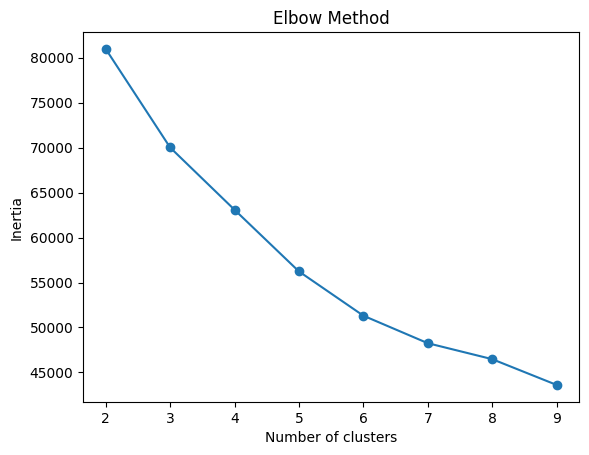

In [40]:
inertia = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [41]:
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.209
K=3, Silhouette Score=0.198
K=4, Silhouette Score=0.192
K=5, Silhouette Score=0.206


## Choosing Number of Clusters

Based on the Elbow Method and Silhouette Score, 3 clusters were selected as a reasonable balance between simplicity and structure.

In [42]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

In [43]:
agg = AgglomerativeClustering(n_clusters=3)
df["cluster_agg"] = agg.fit_predict(X_scaled)

In [44]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

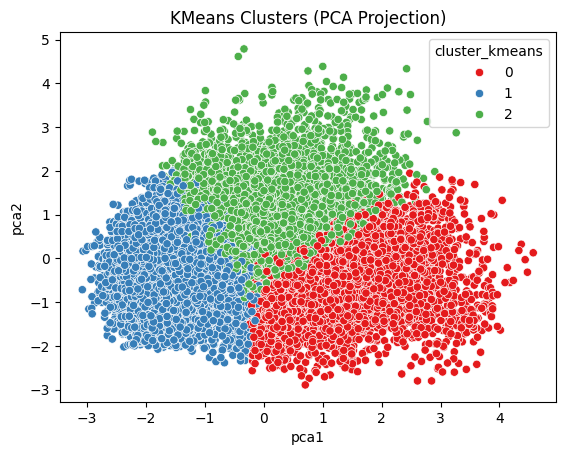

In [45]:
plt.figure()
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster_kmeans", palette="Set1")
plt.title("KMeans Clusters (PCA Projection)")
plt.show()

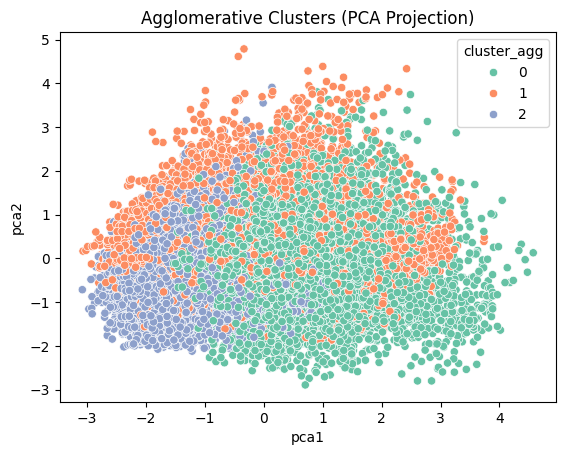

In [46]:
plt.figure()
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster_agg", palette="Set2")
plt.title("Agglomerative Clusters (PCA Projection)")
plt.show()

In [47]:
cluster_summary = df.groupby("cluster_kmeans")[features].mean()
cluster_summary

,temp,hum,windspeed,hr,workingday,cnt
cluster_kmeans,,,,,,
0,0.665431,0.556839,0.189007,15.561032,0.723181,359.116806
1,0.458152,0.772946,0.133801,5.219704,0.678785,67.803746
2,0.339320,0.526495,0.263883,14.739773,0.637910,136.879303


## Cluster Interpretation

Cluster 0 (High Demand):
- Highest average `cnt` (~359)
- Higher temperature and moderate humidity
- Occurs mostly during afternoon and peak hours  
This cluster represents periods of very high bike rental demand.

Cluster 1 (Low Demand):
- Lowest average `cnt` (~67)
- Lower temperature and higher humidity
- Mostly early hours of the day  
This cluster represents periods of minimal bike usage.

Cluster 2 (Medium Demand):
- Moderate average `cnt` (~136)
- Mixed environmental conditions  
This cluster represents typical, average bike rental activity.

## Segmentation Analysis

The clustering analysis revealed clear patterns in bike rental behavior based on both environmental and time-related features. Three distinct clusters were identified, representing different levels of demand.

Cluster 0 corresponds to high-demand periods, with the highest average rental counts. These observations are typically associated with warmer temperatures and occur more frequently during peak hours of the day. Cluster 1 represents low-demand periods, characterized by significantly lower rental activity, often during early hours or less favorable environmental conditions. Cluster 2 reflects medium-demand periods, capturing typical usage levels under average conditions.

The PCA visualization shows that the K-Means algorithm produces relatively well-separated clusters, indicating a clear underlying structure in the data. In contrast, the Agglomerative clustering results in more overlap between groups, suggesting less distinct separation.

Overall, the segmentation is meaningful but not perfectly clean, as some overlap exists between clusters. This is expected in real-world data where multiple factors influence behavior. The results demonstrate that clustering can effectively identify usage patterns and provide insights into different demand segments.

In [48]:
df.to_csv(OUTPUT_FILE, index=False)
print("Clustered dataset saved")

Clustered dataset saved
